# Experiment 1 — Image Scaling and Rotation (From Scratch)

**Objective:** To develop a Python program that reads an image and performs image scaling
and rotation using custom-implemented functions (i.e. without using OpenCV's built-in
functions for the actual transformation math).

**Constraints followed:**
- OpenCV (`cv2`) is used *only* for reading the input image and writing output images.
- The scaling, rotation, and both interpolation schemes (Nearest Neighbour and Bilinear)
  are implemented from first principles using NumPy.

**What this notebook covers:**
1. Reading and preparing a grayscale image
2. Image scaling — Nearest Neighbour interpolation
3. Image scaling — Bilinear interpolation
4. Image rotation — Nearest Neighbour interpolation
5. Image rotation — Bilinear interpolation

Two interpolation strategies are implemented in this notebook:

- **Nearest Neighbour Interpolation:** The output pixel simply takes the intensity value of
  the *closest* pixel in the source image (i.e. the mapped coordinate is rounded to the
  nearest integer). It is fast and simple, but tends to produce blocky, jagged (aliased)
  results, especially when scaling up or rotating.

- **Bilinear Interpolation:** The output pixel value is computed as a weighted average of
  the **4 nearest neighbouring pixels** (top-left, top-right, bottom-left, bottom-right) in
  the source image. The weights depend on how close the mapped (fractional) coordinate is
  to each of the 4 neighbours. This produces smoother results than nearest neighbour, at a
  higher computational cost.

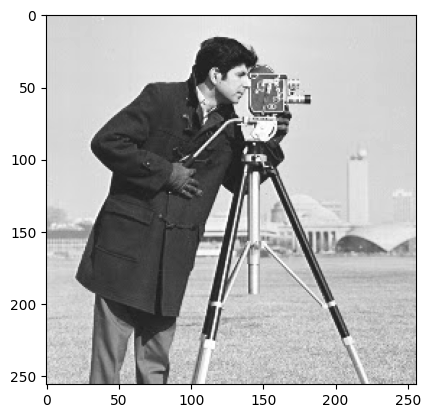

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
pil_image=Image.open("/cameraman.jpg")
pil_image=pil_image.convert("L") #L denotes grayscale
img=np.array(np.asarray(pil_image))
plt.imshow(img,cmap='gray',vmin=0, vmax=255)
plt.show()

Scaling changes the size of an image by a **scaling factor** `s`. For a pixel at output
coordinate `(i, j)`, the corresponding location in the source (input) image is found using
the **inverse mapping**:

```
i_src = i / s
j_src = j / s
```

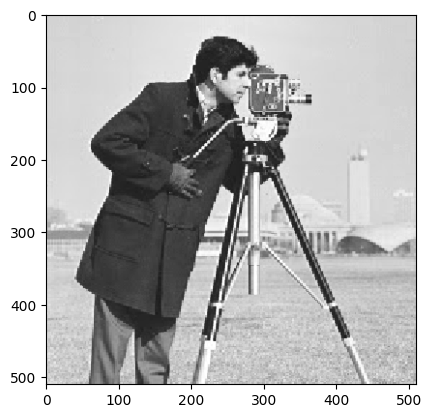

True

In [18]:
scaling_fac=2
size=img.shape
nw=int((size[0]-1)*scaling_fac)
nh=int((size[1]-1)*scaling_fac)
nimg_arr=np.ones((nw,nh))

for i in range(nw):
  for j in range(nh):
    i1=round(i/scaling_fac)
    j1=round(j/scaling_fac)
    nimg_arr[i,j]=img[i1,j1]

plt.imshow(nimg_arr,cmap='gray',vmin=0, vmax=255)
plt.show()
cv2.imwrite("scaleopnear_neigh.jpg",nimg_arr)

### . Image Scaling — Bilinear Interpolation
It performs linear interpolation **twice**:
1. Along the x-direction, between the top pair and the bottom pair, to get `f1` and `f2`.
2. Along the y-direction, between `f1` and `f2`, to get the final interpolated value.

```
f1 = (x2 - x) * I(x1, y1) + (x - x1) * I(x2, y1)
f2 = (x2 - x) * I(x1, y2) + (x - x1) * I(x2, y2)
output(i, j) = (y2 - y) * f1 + (y - y1) * f2

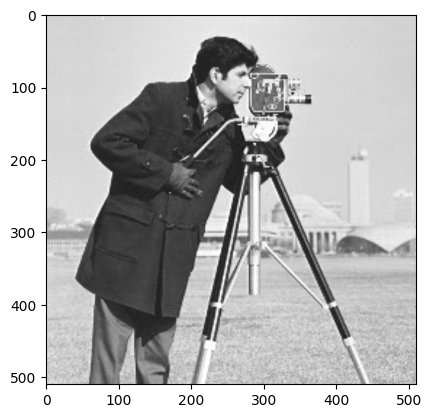

True

In [ ]:
for i in range(nw):
    for j in range(nh):
        x =i/scaling_fac
        y = j/scaling_fac
        x1 = int(x)
        y1 = int(y)

        x2 = min(x1 + 1, size[0] - 1)
        y2 = min(y1 + 1, size[1] - 1)

        f1 =(x2 - x) * img[x1, y1] + (x - x1) * img[x2, y1]
        f2 =(x2 - x) * img[x1, y2] + (x - x1) * img[x2, y2]

        nimg_arr[i,j] =(y2 - y) * f1 + (y - y1) * f2

plt.imshow(nimg_arr, cmap='gray', vmin=0, vmax=255)
plt.show()

cv2.imwrite("scaleop_bilinear.jpg", nimg_arr)

**Step 1 — Output canvas size:** Rotating a rectangle changes its bounding box. The new
width/height that fit the fully rotated image are:

```
new_w = |h*sin(theta)| + |w*cos(theta)|
new_h = |h*cos(theta)| + |w*sin(theta)|
```

**Step 2 — Shift to centre:** Rotation is defined about the origin, so we first shift
coordinates so that the image centre becomes the origin:

```
x = i - new_center_x
y = j - new_center_y
```

**Step 3 — Inverse rotation:** To find the *source* location for output pixel `(x, y)`,
apply the **inverse rotation matrix** (rotate by `-theta`), then shift back to the original
image's centre:

```
x_src = cx + x*cos(theta) + y*sin(theta)
y_src = cy - x*sin(theta) + y*cos(theta)
```

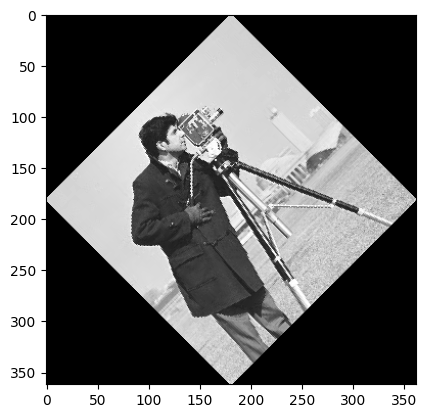

True

In [21]:
theta = 45
theta_rad = np.deg2rad(theta)

size = img.shape
h, w = size

nw = int(abs(h * np.cos(theta_rad)) + abs(w * np.sin(theta_rad)))
nh = int(abs(h * np.sin(theta_rad)) + abs(w * np.cos(theta_rad)))

nimg_arr = np.zeros((nw, nh))

cx, cy = int(w / 2), int(h / 2)
ncx, ncy = int(nw / 2), int(nh / 2)

for i in range(nw):
    for j in range(nh):

        x = i - ncx
        y = j - ncy

        i1 = int(cx + x * np.cos(theta_rad) + y * np.sin(theta_rad))
        j1 = int(cy - x * np.sin(theta_rad) + y * np.cos(theta_rad))

        if 0 <= i1 < h and 0 <= j1 < w:
            nimg_arr[i, j] = img[i1, j1]

plt.imshow(nimg_arr, cmap='gray', vmin=0, vmax=255)
plt.show()
cv2.imwrite("rotateop_nearest.jpg", nimg_arr)

### Image Rotation — Bilinear Interpolation

### Theory
The geometric mapping (steps 1–3 above: canvas size, centring, inverse rotation) is
identical to the Nearest Neighbour case. The only difference is in the final interpolation
step.

Instead of rounding the source coordinate `(x_orig, y_orig)` to a single pixel, we take its
4 integer neighbours — `(x1,y1)`, `(x2,y1)`, `(x1,y2)`, `(x2,y2)` where `x2 = x1+1`,
`y2 = y1+1` — and blend them using the fractional offsets `dx = x_orig - x1`,
`dy = y_orig - y1`:

```
R1 = (1-dx) * I(x1,y1) + dx * I(x2,y1)
R2 = (1-dx) * I(x1,y2) + dx * I(x2,y2)
pixel_value = (1-dy) * R1 + dy * R2
```

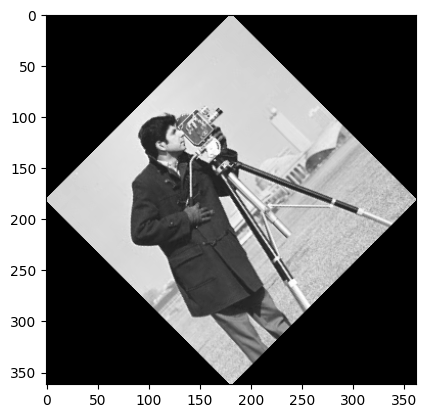

True

In [22]:
for i in range(nw):
    for j in range(nh):
        x = i - ncx
        y = j - ncy

        x_orig = cx + x * np.cos(theta_rad) + y * np.sin(theta_rad)
        y_orig = cy - x * np.sin(theta_rad) + y * np.cos(theta_rad)

        x1 = int(np.floor(x_orig))
        y1 = int(np.floor(y_orig))

        x2 = x1 + 1
        y2 = y1 + 1

        if 0 <= x1 < h and 0 <= y1 < w:
            if x2 >= h:
                x2 = h - 1
            if y2 >= w:
                y2 = w - 1
            dx = x_orig - x1
            dy = y_orig - y1
            if x1 < h and y1 < w:
                if 0 <= x1 < h and 0 <= y1 < w and 0 <= x2 < h and 0 <= y2 < w:
                    R1 = (1 - dx) * img[x1, y1] + dx * img[x2, y1]
                    R2 = (1 - dx) * img[x1, y2] + dx * img[x2, y2]
                    pixel_value = (1 - dy) * R1 + dy * R2
                    nimg_arr[i, j] = pixel_value
plt.imshow(nimg_arr, cmap='gray', vmin=0, vmax=255)
plt.show()
cv2.imwrite("rotateop_bilinear.jpg", nimg_arr)